In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
from collections import defaultdict

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 5
n_var = 100
n_components = 7
n_datapoints = 50000
locs_range = 2
batch_size = 32

In [127]:
import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan


def _compute_log_r(model_trace, guide_trace):
    log_r = MultiFrameTensor()
    stacks = get_plate_stacks(model_trace)
    for name, model_site in model_trace.nodes.items():
        if model_site["type"] == "sample":
            log_r_term = model_site["log_prob"]
            if not model_site["is_observed"]:
                log_r_term = log_r_term - guide_trace.nodes[name]["log_prob"]
            log_r.add((stacks[name], log_r_term.detach()))
    return log_r

class Print_Trace_ELBO(ELBO):
    """
    A trace implementation of ELBO-based SVI. The estimator is constructed
    along the lines of references [1] and [2]. There are no restrictions on the
    dependency structure of the model or the guide. The gradient estimator includes
    partial Rao-Blackwellization for reducing the variance of the estimator when
    non-reparameterizable random variables are present. The Rao-Blackwellization is
    partial in that it only uses conditional independence information that is marked
    by :class:`~pyro.plate` contexts. For more fine-grained Rao-Blackwellization,
    see :class:`~pyro.infer.tracegraph_elbo.TraceGraph_ELBO`.

    References

    [1] Automated Variational Inference in Probabilistic Programming,
        David Wingate, Theo Weber

    [2] Black Box Variational Inference,
        Rajesh Ranganath, Sean Gerrish, David M. Blei
    """

    def _get_trace(self, model, guide, args, kwargs):
        """
        Returns a single trace from the guide, and the model that is run
        against it.
        """
        model_trace, guide_trace = get_importance_trace(
            "flat", self.max_plate_nesting, model, guide, args, kwargs
        )
        if is_validation_enabled():
            check_if_enumerated(guide_trace)
        return model_trace, guide_trace

    def loss(self, model, guide, *args, **kwargs):
        """
        :returns: returns an estimate of the ELBO
        :rtype: float

        Evaluates the ELBO with an estimator that uses num_particles many samples/particles.
        """
        elbo = 0.0
        for model_trace, guide_trace in self._get_traces(model, guide, args, kwargs):
            elbo_particle = torch_item(model_trace.log_prob_sum()) - torch_item(
                guide_trace.log_prob_sum()
            )
            elbo += elbo_particle / self.num_particles

        loss = -elbo
        warn_if_nan(loss, "loss")
        return loss

    def _differentiable_loss_particle(self, model_trace, guide_trace):
        elbo_particle = 0
        surrogate_elbo_particle = 0
        log_r = None

        # compute elbo and surrogate elbo
        for name, site in model_trace.nodes.items():
            if site["type"] == "sample":
                print(name,site["log_prob_sum"])
                elbo_particle = elbo_particle + torch_item(site["log_prob_sum"])
                surrogate_elbo_particle = surrogate_elbo_particle + site["log_prob_sum"]

        for name, site in guide_trace.nodes.items():
            if site["type"] == "sample":
                log_prob, score_function_term, entropy_term = site["score_parts"]
                print(name,site["log_prob_sum"])
                elbo_particle = elbo_particle - torch_item(site["log_prob_sum"])

                if not is_identically_zero(entropy_term):
                    surrogate_elbo_particle = (
                        surrogate_elbo_particle - entropy_term.sum()
                    )

                if not is_identically_zero(score_function_term):
                    if log_r is None:
                        log_r = _compute_log_r(model_trace, guide_trace)
                    site = log_r.sum_to(site["cond_indep_stack"])
                    surrogate_elbo_particle = (
                        surrogate_elbo_particle + (site * score_function_term).sum()
                    )

        return -elbo_particle, -surrogate_elbo_particle

    def differentiable_loss(self, model, guide, *args, **kwargs):
        """
        Computes the surrogate loss that can be differentiated with autograd
        to produce gradient estimates for the model and guide parameters
        """
        loss = 0.0
        surrogate_loss = 0.0
        for model_trace, guide_trace in self._get_traces(model, guide, args, kwargs):
            loss_particle, surrogate_loss_particle = self._differentiable_loss_particle(
                model_trace, guide_trace
            )
            surrogate_loss += surrogate_loss_particle / self.num_particles
            loss += loss_particle / self.num_particles
        warn_if_nan(surrogate_loss, "loss")
        return loss + (surrogate_loss - torch_item(surrogate_loss))

    def loss_and_grads(self, model, guide, *args, **kwargs):
        """
        :returns: returns an estimate of the ELBO
        :rtype: float

        Computes the ELBO as well as the surrogate ELBO that is used to form the gradient estimator.
        Performs backward on the latter. Num_particle many samples are used to form the estimators.
        """
        loss = 0.0
        # grab a trace from the generator
        for model_trace, guide_trace in self._get_traces(model, guide, args, kwargs):
            loss_particle, surrogate_loss_particle = self._differentiable_loss_particle(
                model_trace, guide_trace
            )
            loss += loss_particle / self.num_particles

            # collect parameters to train from model and guide
            trainable_params = any(
                site["type"] == "param"
                for trace in (model_trace, guide_trace)
                for site in trace.nodes.values()
            )

            if trainable_params and getattr(
                surrogate_loss_particle, "requires_grad", False
            ):
                surrogate_loss_particle = surrogate_loss_particle / self.num_particles
                surrogate_loss_particle.backward(retain_graph=self.retain_graph)
        warn_if_nan(loss, "loss")
        return loss


In [128]:
grads=defaultdict(list)

import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan

class SafeSVI(pyro.infer.abstract_infer.TracePosterior):
    '''A version of pyro.infer.SVI that skips steps with loss more than X sigma from the running mean loss'''
    def __init__(
        self,
        model,
        guide,
        optim,
        loss,
        loss_and_grads=None,
        clip_std_multiplier=6.0,
        window_size=1000,  # Default window size of 300
        **kwargs
    ):
        super().__init__(**kwargs)
        self.model = model
        self.guide = guide
        self.optim = optim
        self.record = False
        self.clip_std_multiplier = clip_std_multiplier
        self.window_size = window_size
        self.losses = []  # Store recent losses to calculate running stats

        if not isinstance(optim, pyro.optim.PyroOptim):
            raise ValueError("Optimizer should be an instance of pyro.optim.PyroOptim class.")

        if isinstance(loss, ELBO):
            self.loss = loss.loss
            self.loss_and_grads = loss.loss_and_grads
        else:
            if loss_and_grads is None:
                def _loss_and_grads(*args, **kwargs):
                    loss_val = loss(*args, **kwargs)
                    if getattr(loss_val, "requires_grad", False):
                        loss_val.backward(retain_graph=True)
                    return loss_val
                self.loss_and_grads = _loss_and_grads
            else:
                self.loss_and_grads = loss_and_grads

    def _traces(self, *args, **kwargs):
        for i in range(self.num_samples):
            guide_trace = poutine.trace(self.guide).get_trace(*args, **kwargs)
            model_trace = poutine.trace(
                poutine.replay(self.model, trace=guide_trace)
            ).get_trace(*args, **kwargs)
            yield model_trace, 1.0

    def evaluate_loss(self, *args, **kwargs):
        with torch.no_grad():
            loss = self.loss(self.model, self.guide, *args, **kwargs)
            return torch_item(loss)

    def step(self, *args, **kwargs):
        # Compute loss and gradients
        with poutine.trace(param_only=True) as param_capture:
            loss = self.loss_and_grads(self.model, self.guide, *args, **kwargs)
    
        loss_val = torch_item(loss)
        self.losses.append(loss_val)
        # Keep only the last `window_size` losses
        if len(self.losses) > self.window_size:
            self.losses.pop(0)
        # Extract params early to ensure they are defined for later use
        params = set(site["value"].unconstrained() for site in param_capture.trace.nodes.values())
        
        # Calculate running mean and std only if we have enough data
        if len(self.losses) >= self.window_size:
            running_mean = np.mean(self.losses)
            running_std = np.std(self.losses)
            #print(loss, running_mean,running_std)
            if ((loss > running_mean-running_std*self.clip_std_multiplier) and (loss < running_mean+running_std*self.clip_std_multiplier)):
                # Perform optimization step
                self.optim(params)
            else:
                print('STEP SKIPPED')
        else:
            self.optim(params)
        
        if self.record:
            for name, value in pyro.get_param_store().named_parameters():
                grads[name].append(value.grad.detach().cpu().numpy())
        
        # Zero gradients
        pyro.infer.util.zero_grads(params)
    
        return loss_val

In [210]:
import torch.nn as nn

class MeanTracker(nn.Module):#,nn.modules.lazy.LazyModuleMixin
    def __init__(self, num_categories, num_features, momentum=0.01,device=None,dtype=torch.float):
        super(MeanTracker, self).__init__()
        self.num_categories = num_categories
        self.num_features = num_features
        self.momentum = momentum
        
        # Register buffers for running means and variances
        self.register_buffer('running_means', torch.zeros(num_categories, num_features))
        self.register_buffer('num_batches_tracked', torch.zeros(num_categories))
        self.initialized=False
    
    def update_running_means(self, input, category):
        # input: [batch_size, num_features]
        # category: [batch_size, num_categories] one-hot encoded            
        
        batch_size = input.size(0)
        category_sum = category.sum(dim=0).detach()  # [num_categories]
        
        # Calculate means and variances for each category
        category_sum_expanded = category_sum.unsqueeze(1)  # [num_categories, 1]
        category_sum_expanded = category_sum_expanded+1e-5  # Avoid division by zero
        category_sum_norm = (category_sum/category_sum.sum()).unsqueeze(1)

        
        means = (category.T @ input) / category_sum_expanded  # [num_categories, num_features]

        if not self.initialized:
            self.running_means=means.detach()
            self.initialized=True

        cur_momentum = self.momentum * category_sum_norm
        self.running_means = (1 - cur_momentum) * self.running_means + (cur_momentum * means.detach())
        self.num_batches_tracked += category_sum.detach()

    def get_running_means(self):
        return self.running_means

    def get_running_vars(self):
        return self.running_vars


class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)
        self.temperature=0.1
        self.mean_tracker=MeanTracker(self.n_components, self.n_var)
    
    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.randn(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 25 * torch.ones(self.n_var, device=device), constraint=constraints.positive)

                taxon_probs=pyro.sample('taxon_probs',dist.Dirichlet(data.new_ones(data.shape[0],self.n_components),validate_args=True))
                taxon = pyro.sample("taxon",antipode.model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*data.new_ones(1),probs=taxon_probs,validate_args=True))                    
                
                latent = pyro.sample('latent', dist.Normal(taxon@locs, taxon@scales+1e-4).to_event(1))
                out_mu = latent @ transform_matrix + taxon @ intercept
                norm_mu = torch.nn.functional.log_softmax(out_mu,dim=-1)
                #softmax_shift = pyro.param('softmax_shift', out_mu.detach().exp().sum(-1).mean().log())
                softmax_shift = pyro.param('softmax_shift', torch.zeros(1,device=data.device))
                softmax_shift2 = pyro.param('softmax_shift2', torch.zeros(1,device=data.device))
                #logits = out_mu - total_counts.log() + l.log() - softmax_shift
                logits = norm_mu - total_counts.log() + l.log() 
                recon = pyro.sample('obs', dist.NegativeBinomial(total_count=total_counts+1e-1, logits=logits,validate_args=False).to_event(1), obs=data)
            
            self.mean_tracker.update_running_means((data.T/data.sum(-1)).T,taxon)
            W_squared=transform_matrix**2
            diagonal_elements = torch.sum(W_squared, dim=0)  # size: (number_var,)
            diagonal_elements = diagonal_elements.unsqueeze(0).expand(self.n_components, -1)  # size: (number_components, number_var)
            diagonal_covariance = torch.matmul(scales**2, W_squared)  # size: (number_components, number_var)
            standard_deviations = torch.sqrt(diagonal_covariance)  # size: (number_components, number_var)
            #print((torch.nn.functional.log_softmax(locs @ transform_matrix + intercept)).min(),(torch.nn.functional.log_softmax(locs @ transform_matrix + intercept)).max())
            #print(self.mean_tracker.running_means.min(),self.mean_tracker.running_means.max())
            # pyro.sample('obs_running',dist.Normal(loc=torch.nn.functional.log_softmax(locs @ transform_matrix + intercept) ,scale=standard_deviations).to_event(2),obs=self.mean_tracker.running_means)
            running_scales=pyro.param('running_scale',torch.ones(self.n_var,device=device), constraint=constraints.positive)
            pyro.sample('obs_running',dist.Normal(loc=torch.nn.functional.log_softmax(locs @ transform_matrix + intercept) ,scale=running_scales+1e-4).to_event(2),obs=(self.mean_tracker.running_means+1e-9).log())
                
    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std+1e-4).to_event(1))
                taxon_probs=pyro.sample('taxon_probs',dist.Delta(antipode.model_functions.safe_softmax(self.classifier(latent),dim=-1)).to_event(1))
                taxon = pyro.sample("taxon",antipode.model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*data.new_ones(1),probs=taxon_probs,validate_args=True))

In [211]:
    # einsum_str = ','.join(f'...z{chr(65 + i)}' for i, _ in enumerate(tensors))
    # einsum_str += '->...' + ''.join(chr(65 + i) for i, _ in enumerate(tensors))
    # out=torch.einsum(einsum_str, * [x/(x.sum(-1,keepdim=True)) for x in tensors])[*indexing_none_list(unsqueeze)]

In [212]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 12*torch.rand(n_var)-6.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'transform_matrix':transform_matrix,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)

In [213]:
(data>0).sum(0)

tensor([30839, 31781, 37080, 11646,  6854, 38842,    10, 17874, 35730, 10953,
         5268, 13499,  2379,    74,  3179,  3896,  1387,  7526,    11,   478,
         5917,    95, 11776, 16865,   622,  2121,   246,  1183, 13417, 26629,
        12467,  9372, 16022,   339, 20391,  2248,  8178,  6672, 11328,  9247,
         5351,   525, 37551,  3027, 38070, 40910,    14,  8022,  1130, 11760,
         3278,  5520,  9962,  2008, 15185,  1481,  2712, 12789, 13369,   541,
        23418,  6426, 38260,   220,  9198,  7855,  1079, 14849,  3830, 13962,
        24246,   364,   293, 20291, 10555,   362,  9508, 28830,  2628,  6543,
         5536, 12135, 19366,  7883, 25357,  7944, 15247,  6453,  3940, 23942,
        23151, 12217,   680, 17629,   676,  1220,   213, 23667,    66, 11982])

In [214]:
# seaborn.histplot(np.log(data.flatten()+0.1))

In [215]:
# seaborn.histplot(data.sum(1).flatten(),bins=10)

In [216]:
adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [282]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)
grads=defaultdict(list)

# SVI setup
adam_params = {"lr": 0.001}
optimizer = Adam(adam_params)
svi = SVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.JitTrace_ELBO())#Print_Trace_ELBO()

# Training loop
num_iterations = 30
losses = []

In [283]:
for i in tqdm.tqdm(range(num_iterations)):
    svi.record=False
    if i==num_iterations-1:
        svi.record=True
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
        #if loss >0.6:
        #    print('EXPLODE KLASLKJASLDKFJALSKDJFALKSDJFLKAJSDFLKAJSDFKLJASLKDFJALKSDJFKLASDJFLKAJSDFLKJASDFLKJASLKDFJASDF')
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  0%|          | 0/30 [00:00<?, ?it/s]/scratch/fast/17694241/ipykernel_125518/706305604.py:99: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  pyro.sample('obs_running',dist.Normal(loc=torch.nn.functional.log_softmax(locs @ transform_matrix + intercept) ,scale=running_scales+1e-4).to_event(2),obs=(self.mean_tracker.running_means+1e-9).log())
/scratch/fast/17694241/ipykernel_125518/706305604.py:99: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  pyro.sample('obs_running',dist.Normal(loc=torch.nn.functional.log_softmax(locs @ transform_matrix + intercept) ,scale=running_scales+1e-4).to_event(2),obs=(self.mean_tracker.running_means+1e-9).log())
  3%|▎         | 1/30 [00:21<10:33, 21.85s/it]

Iteration 0 : Loss 0.6454441547393799


  7%|▋         | 2/30 [00:41<09:40, 20.75s/it]

Iteration 1 : Loss 0.46208053827285767


 10%|█         | 3/30 [00:59<08:37, 19.15s/it]

...

Iteration 27 : Loss 0.1129922866821289


 97%|█████████▋| 29/30 [08:16<00:16, 16.85s/it]

Iteration 28 : Loss 0.18090426921844482


100%|██████████| 30/30 [08:33<00:00, 17.12s/it]

Iteration 29 : Loss 0.12578582763671875
Training complete.


In [284]:
pyro.param('scales')

tensor([[2.5632, 0.6663, 4.4915, 0.3419, 0.7475, 0.6741, 0.5265, 0.5133, 0.8580,
         0.9556],
        [1.3953, 0.5820, 0.4846, 0.4151, 4.5938, 2.1451, 0.6438, 0.5455, 3.2319,
         2.4177],
        [3.2539, 0.7423, 0.6309, 2.7292, 2.5323, 1.7319, 1.9433, 0.5633, 0.6817,
         0.8640],
        [1.6334, 2.0255, 1.2180, 1.6582, 2.8588, 1.6768, 1.0179, 1.2087, 1.3756,
         1.8018],
        [1.3528, 1.3716, 1.4575, 0.9109, 2.7170, 1.9390, 0.9553, 0.9592, 1.4321,
         2.2821],
        [1.5844, 0.4548, 0.4263, 0.3500, 0.9625, 1.3995, 0.6027, 1.3369, 5.2726,
         0.8228],
        [1.9152, 0.8970, 0.8337, 2.2396, 1.6369, 2.9880, 1.0716, 0.4912, 1.7753,
         2.3213],
        [2.1893, 1.9363, 1.1400, 2.9037, 3.8095, 1.7203, 1.9095, 0.6098, 0.6491,
         1.9360],
        [1.5299, 1.8667, 1.1549, 1.1167, 3.0829, 1.5538, 2.1683, 1.2210, 1.6195,
         2.0547],
        [2.0888, 2.5703, 0.8646, 4.4500, 2.0259, 1.6134, 1.0501, 1.8146, 0.9524,
         1.3570],
        [1

In [285]:
pyro.param('running_scale').min()

tensor(0.0020, device='cuda:0', grad_fn=<MinBackward1>)

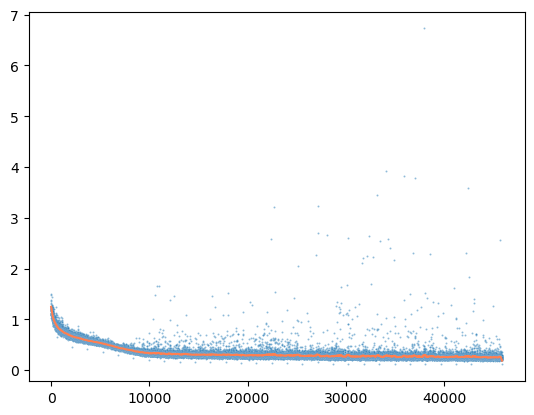

In [286]:
antipode.plotting.plot_loss(losses[1000:])

In [287]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [288]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [289]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


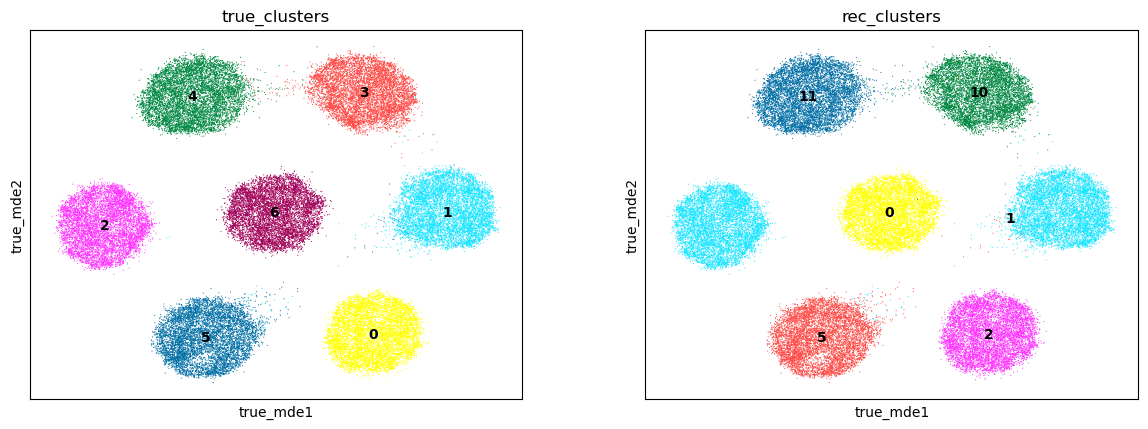

In [290]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


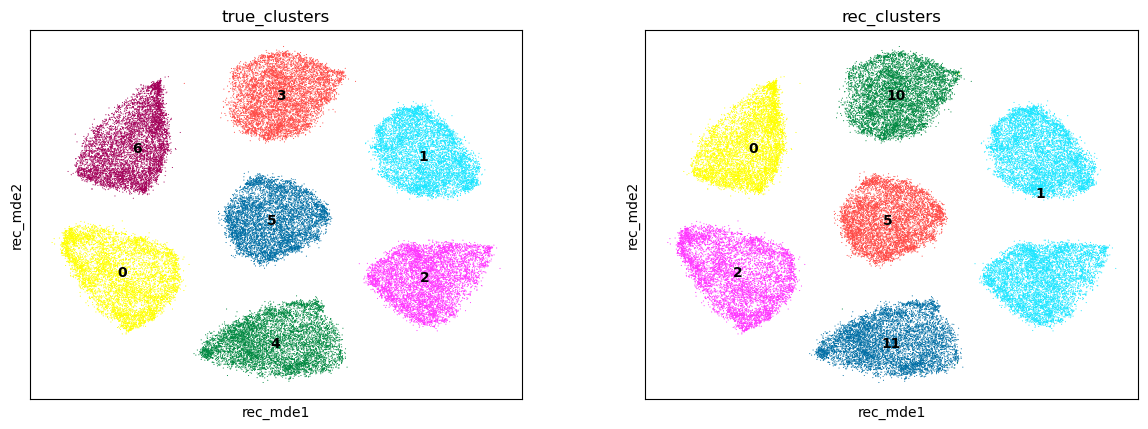

In [291]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [292]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
included_clusters=pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters'])
learned_means=learned_means[included_clusters,:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

100%|██████████| 6/6 [00:00<00:00, 187.96it/s]


In [293]:
toy_model.mean_tracker.running_means[included_clusters,:].shape

torch.Size([6, 100])

In [294]:
import sys
sys.path.append('/home/matthew.schmitz/utils/mts-utils/')
from genomics import sc_analysis


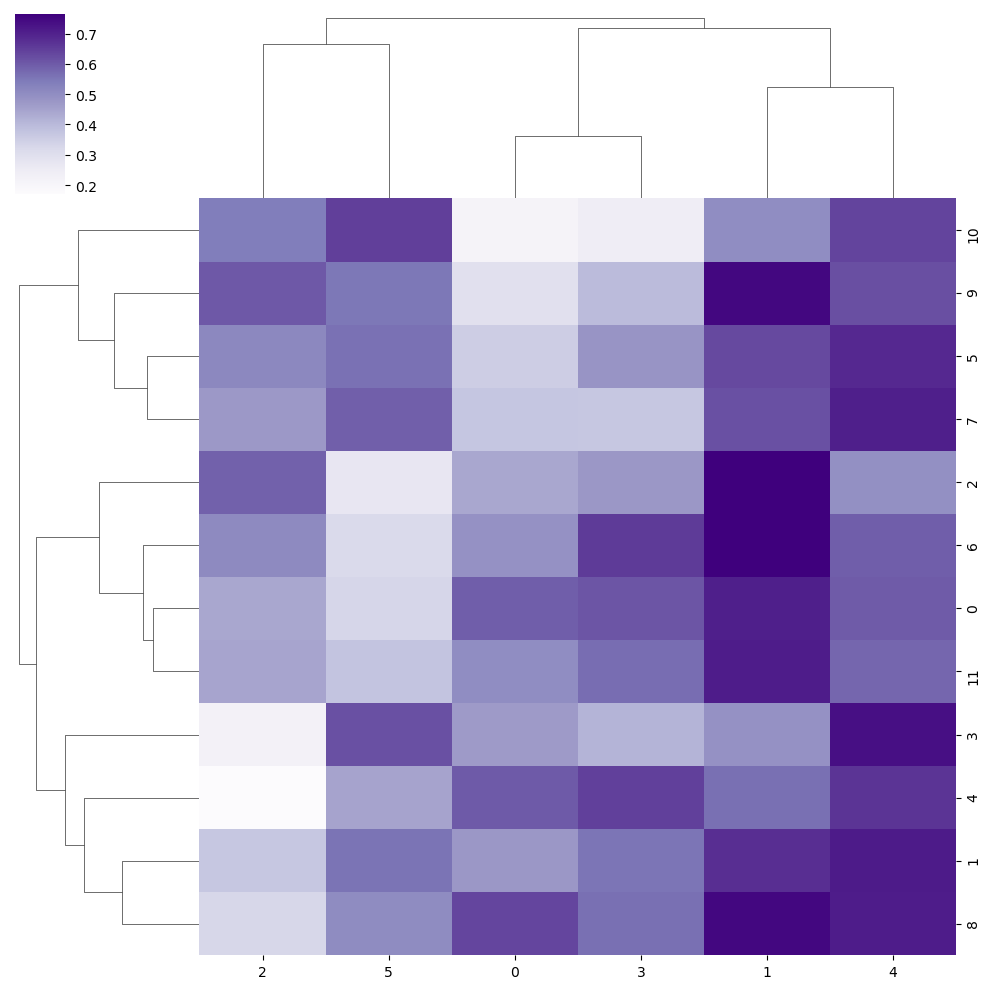

In [295]:
correlations=[]
#original_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
seaborn.clustermap(sc_analysis.corr2_coeff((toy_model.mean_tracker.running_means.detach()+1e-9).log().cpu().numpy(),actual_means),cmap='Purples')



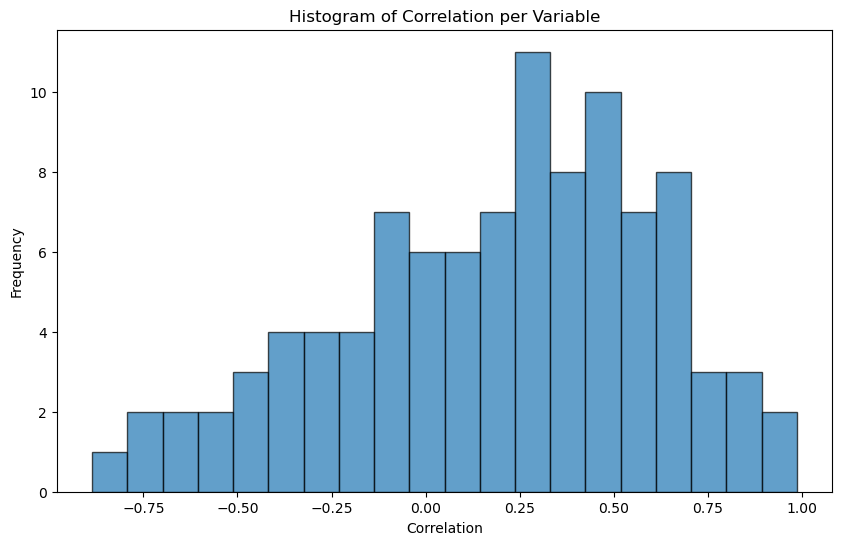

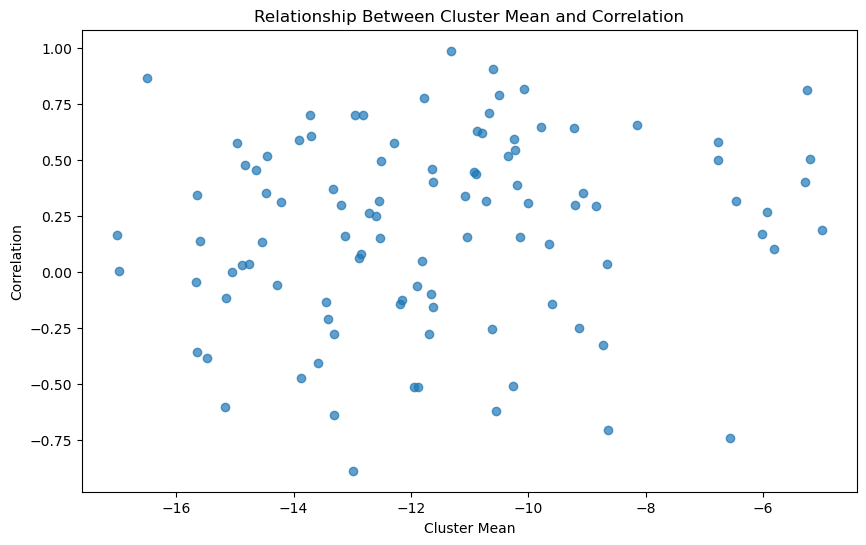

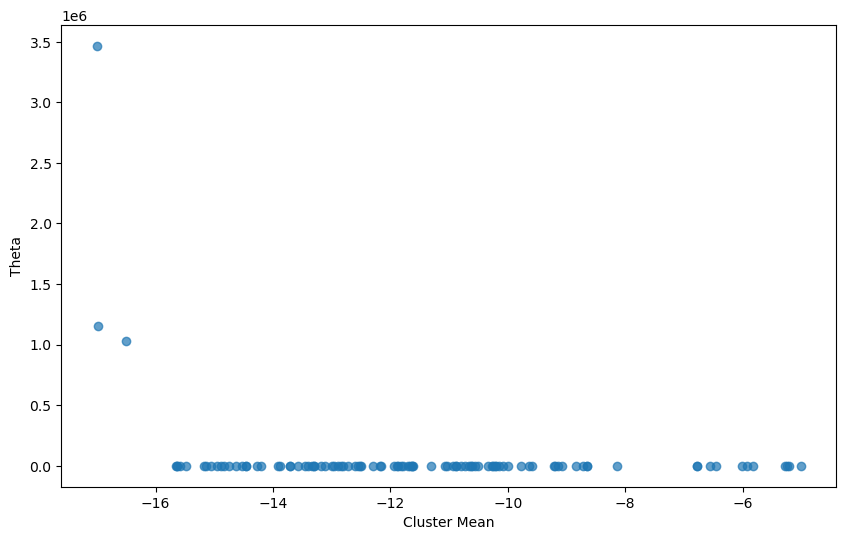

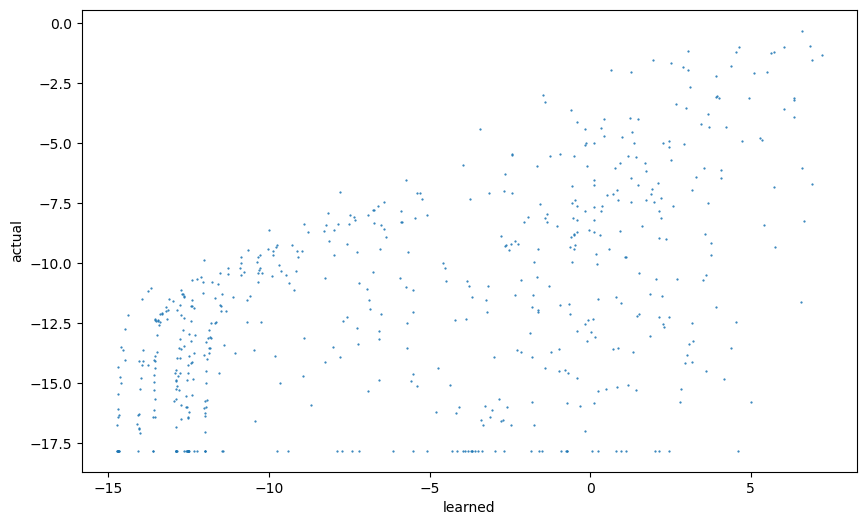

In [296]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(learned_means.flatten(),actual_means.flatten(),s=0.3)
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


In [297]:
zdw_grads=np.absolute(np.stack(grads['transform_matrix'])).mean(0)
seaborn.scatterplot(x=actual_means.mean(0),y=np.log(zdw_grads.mean(0)),s=1)
plt.xlabel('var mean')
plt.ylabel('abs gradient')

ValueError: need at least one array to stack